# Generating marker binary masks per block 

Run using `mesmer_pypi` conda environment

Think of this as separating background from true signal

In [1]:
import os 
import re 
import tifffile 
import numpy as np 
import cv2
from skimage.filters import frangi
import matplotlib.pyplot as plt
import pandas as pd 
from typing import List, Tuple, Dict

# Functions

In [2]:
def remove_background(img: np.ndarray, radius: int = 15) -> np.ndarray:
    se = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2*radius+1, 2*radius+1)
    )
    background = cv2.morphologyEx(img, cv2.MORPH_OPEN, se)
    return cv2.subtract(img, background)

def ridge_enhance(img: np.ndarray) -> np.ndarray:
    img_f = img.astype(np.float32) / 255.0

    ridges = frangi(
        img_f,
        sigmas=[1.0, 1.5, 2.0, 2.5],
        alpha=0.5,
        beta=0.5,
        gamma=15,
        black_ridges=False
    )
    return (255 * ridges / ridges.max()).astype(np.uint8)


def normalize(img: np.ndarray, p_low: int, p_high: int, marker_name: str | None, manual_thresholds: Dict[str, Tuple[int]] | None) -> np.ndarray:
    if manual_thresholds is None:
        img_1d = img.flatten()
        img_1d = img_1d[img_1d > 0]
        p_low, p_high = np.percentile(img_1d, (p_low, p_high))
    else: 
        if marker_name is None:
            raise ValueError(f"`marker_name` arg cannot be None when manual_thresholds is not None")
        p_low, p_high = manual_thresholds[marker_name]
    print(f"low percentile values: {p_low}")
    print(f"high percentile value: {p_high}")
    img = np.clip(img, p_low, p_high)
    norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    norm = norm.astype('uint8')
    return norm 

def clip_no_normalize(img: np.ndarray, p_low: int, p_high: int, marker_name: str | None, manual_thresholds: Dict[str, Tuple[int]] | None) -> np.ndarray:
    if manual_thresholds is None:
        img_1d = img.flatten()
        img_1d = img_1d[img_1d > 0]
        p_low, p_high = np.percentile(img_1d, (p_low, p_high))
    else: 
        if marker_name is None:
            raise ValueError(f"`marker_name` arg cannot be None when manual_thresholds is not None")
        p_low, p_high = manual_thresholds[marker_name]
    print(f"low percentile values: {p_low}")
    print(f"high percentile value: {p_high}")
    img = np.clip(img, p_low, p_high)
    img = img.astype('uint8')
    return img 

def adaptive_binarize(img: np.ndarray, C: int, block_size: int) -> np.ndarray:
    return cv2.adaptiveThreshold(
        img,
        255,
        # cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        blockSize=block_size,
        C=C
    )
    
def otsu_binarize(img: np.ndarray) -> np.ndarray:
    blur = cv2.GaussianBlur(img, (5,5), 0)
    _, thresh_img = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh_img

    
def cleanup(mask, kernel_size: int = 3) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))

    # remove speckle noise
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # bridge small gaps in membranes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

def show_overlay(img, binary, alpha=0.5):
    plt.figure(figsize=(6, 6))

    plt.imshow(img, cmap="cividis") # cividis
    plt.imshow(binary, cmap="autumn", alpha=alpha) # autumn
    plt.title("Normalized image and final mask")
    plt.axis("off")
    plt.show()

def rgb_overlay(img, binary):
    rgb = np.zeros((*img.shape, 3))
    
    # Base image → cyan
    rgb[..., 1] = img
    rgb[..., 2] = img

    # Mask → red
    rgb[..., 0] = binary
    print(np.unique(binary))

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.title("Normalized image and final mask")
    plt.axis("off")
    plt.show()
    
def membrane_mask_from_channel(img: np.ndarray, plot_intermediates: bool, plot_overlay: bool, marker_name: str, 
                               kernel_size: int, p_low, p_high, C: int, block_size: int, manual_thresholds: Dict[str, Tuple[int]] | None) -> np.ndarray:    
    bg_removed = remove_background(img, radius=15)        
    # ridges = ridge_enhance(bg_removed)
    norm = normalize(bg_removed, p_low, p_high, manual_thresholds = manual_thresholds, marker_name = marker_name)
    # norm = clip_no_normalize(bg_removed, p_low, p_high, manual_thresholds = manual_thresholds, marker_name = marker_name)
    binary = adaptive_binarize(norm, C= C, block_size= block_size)
    # binary = otsu_binarize(norm)
    # cleaned = cleanup(binary, kernel_size = kernel_size)
    cleaned = binary 
    if plot_intermediates or plot_overlay: 
        print(marker_name)
        
    if plot_intermediates:
        plt.imshow(img, cmap= "grey")
        plt.title(f"Original channel")
        plt.show()
        
        plt.imshow(bg_removed, cmap='grey')
        plt.title(f"Background subtracted channel")
        plt.show()
        
        # plt.imshow(ridges, cmap= "grey")
        # plt.title(f"Ridge enhanced channel")
        # plt.show()
        
        plt.imshow(norm, cmap= "grey")
        plt.title(f"Normalized channel")
        plt.show()
        
        plt.imshow(binary, cmap= "grey")
        plt.title(f"Binarized channel")
        plt.show()
        
        plt.imshow(cleaned, cmap= "grey")
        plt.title(f"Cleaned channel")
        plt.show()
        
    if plot_overlay:
        show_overlay(norm, cleaned, alpha= 0.5)
        #rgb_overlay(norm, cleaned)
    
    return binary

def channel_mask_wrapper(
    img: np.ndarray, 
    markers_df: pd.DataFrame, 
    plot_intermediates: bool, 
    plot_overlay: bool, 
    kernel_size: int, 
    p_low: int,
    p_high: int, 
    C: int, 
    block_size: int,
    save_new_img: bool, 
    concat_new_img: bool,
    save_masked_img: bool,
    manual_thresholds: Dict[str, Tuple[int]] | None = None, 
    out_dir: str | None = None, 
    file_name: str | None = None, 
    mem_markers: List[str] = ['CD44', 'CD4', 'CD8', 'CD20', 'CD3e', 'b-Catenin1', 'Collagen IV', 'Bcl-2'],
    nuc_markers: List[str] = ['Ki67', 'FOXP3', 'TP63'], 
    cyto_markers: List[str] = ['K5', 'CD68', 'CD31', 'K14', 'Pan-Cytokeratin', 'CD11c', 'HLA-A', 'Vimentin', 'CD40', 'K8', 'HLA-DR', 'K10', 'CD141', 'CD34']
    ) -> np.ndarray: 
    all_marker_names = mem_markers + nuc_markers + cyto_markers  
    all_marker_indices = [markers_df.loc[markers_df["marker_name"] == marker_name, "row_num"].values[0] for marker_name in all_marker_names]
    thresh_marker_list = [None] * len(all_marker_indices)
    for i, (marker_name, marker_index) in enumerate(zip(all_marker_names, all_marker_indices)):
        print(f"Starting {marker_name}")
        thresh_marker = membrane_mask_from_channel(
            img[marker_index], 
            plot_intermediates = plot_intermediates, 
            plot_overlay = plot_overlay, 
            marker_name = marker_name, 
            kernel_size = kernel_size,
            p_low = p_low,
            p_high = p_high,
            C = C,
            block_size = block_size,
            manual_thresholds = manual_thresholds
        )
        thresh_marker_list[i] = thresh_marker[np.newaxis,...]
        print(f"Done with {marker_name}")
        print("")
    new_img = np.concatenate(thresh_marker_list)
    
    if save_new_img or concat_new_img:
        if file_name is None:
            raise ValueError("file_name arg cannot be None when save_new_img = True") 
        if out_dir is None:
            raise ValueError("out_dir arg cannot be None when save_new_img = True") 
        new_marker_names = [marker_name + "_mask" for marker_name in all_marker_names]
    
    if save_new_img:
        tifffile.imwrite(
            os.path.join(out_dir, file_name+"_auto_thresh_binary_masks.ome.tif"), 
            new_img, 
            metadata={'Channel': {'Name': new_marker_names}},
        )
        new_marker_df = pd.DataFrame({
            "cycle"       : [1] * len(new_marker_names),
            "marker_name" : new_marker_names, 
            "row_num"     : list(range(0, len(new_marker_names)))
        })
        new_marker_df.to_csv(os.path.join(out_dir, "mask_markers.csv"), index= False)
        
    if concat_new_img:
        org_and_new_img = np.concatenate((img, new_img))
        org_and_new_marker_names = markers_df["marker_name"].tolist() + new_marker_names
        tifffile.imwrite(
            os.path.join(out_dir, file_name+"_org_and_auto_thresh_binary_masks.ome.tif"), 
            org_and_new_img, 
            metadata={'Channel': {'Name': org_and_new_marker_names}},
        )
        
        # markers_df.loc[markers_df["marker_name"].isin()].to_csv(os.path.join(out_dir, "mask_markers.csv"), index= False)
    if save_masked_img: 
        masked_img = img[all_marker_indices, ...] * new_img.astype(bool)
        masked_marker_df = pd.DataFrame({
            "cycle"       : [1] * len(all_marker_names),
            "marker_name" : all_marker_names, 
            "row_num"     : list(range(0, len(all_marker_names)))
        })
        masked_marker_df.to_csv(os.path.join(out_dir, "mask_filt_markers.csv"), index= False)
            
        tifffile.imwrite(
            os.path.join(out_dir, file_name+"_auto_thresh_binary_filt_masks.ome.tif"), 
            masked_img, 
            metadata={'Channel': {'Name': all_marker_names}},
        )
        
    return new_img 

# Thresholding markers in images

# Block 1

In [13]:
block1_clip_threshs = {
    "K14"  : (10, 180),
    'CD44' : (20, 115),
    'CD4'  : (10, 120),
    'CD8'  : (10, 120), 
    'CD3e' : (10, 120),
    'CD20' : (30, 70), # Really high background here.
    'b-Catenin1'  : (40, 140),
    'Collagen IV' : (30, 100),
    'Bcl-2' : (1, 140), # This stain is blurry and high background. The rolling ball background subtraction removes most of the issue, but the blurriness makes it difficult to get even positive calling. I think b/c there aren't positive ridges next to clear background.
    'Ki67'  : (20, 140),
    'FOXP3' : (50, 70),
    'TP63'  : (80, 125), # NOTE: TP63 high cells only (nuclear stain)
    'K5'    : (70, 140),
    'CD68'  : (50, 110), # 
    'CD31'  : (30, 100), # NOTE: This is only CD31 high 
    'Pan-Cytokeratin' : (10, 180),
    'CD11c'    : (80, 190),
    'HLA-A'    : (40, 180),
    'Vimentin' : (140, 200),
    'CD40'     : (100, 180),
    'K8'       : (70, 140), # (70, 140)
    'HLA-DR'   : (20, 120),
    'K10'      : (20, 140),
    'CD141'    : (30, 60),
    'CD34'     : (40, 180)
} 

## T2008_7M

In [14]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/T2008_7M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2008_7M"


thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2066_8M

In [15]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/T2066_8M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2066_8M"


thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2033_9F

In [16]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/T2033_9F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2033_9F"

thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P33_10M

In [17]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/P33_10M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P33_10M"


thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P31_27F

In [18]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/P31_27F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P31_27F"

thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P32_46F

In [19]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/P32_46F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P32_46F"


thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P37_62F

In [20]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block1_patches/P37_62F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P37_62F"


thresh_keyword = "block1_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block1_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Block 2

In [4]:
block2_clip_threshs = {
    "K14"  : (5, 110),
    'CD44' : (20, 115),
    'CD4'  : (20, 100),
    'CD8'  : (20, 100), 
    'CD3e' : (10, 120),
    'CD20' : (50, 110), # Really high background here.
    'b-Catenin1'  : (45, 130),
    'Collagen IV' : (60, 130),
    'Bcl-2' : (75, 140),
    'Ki67'  : (15, 100),
    'FOXP3' : (50, 75),
    'TP63'  : (80, 100), # NOTE: TP63 high cells only (nuclear stain)
    'K5'    : (40, 160),
    'CD68'  : (50, 110), # 
    'CD31'  : (65, 193), # NOTE: This is only CD31 high 
    'Pan-Cytokeratin' : (20, 180),
    'CD11c'    : (90, 160),
    'HLA-A'    : (30, 161),
    'Vimentin' : (160, 240),
    'CD40'     : (100, 210),
    'K8'       : (70, 140), # (70, 140)
    'HLA-DR'   : (12, 120),
    'K10'      : (20, 140),
    'CD141'    : (35, 60),
    'CD34'     : (40, 180)
} 

## P34_29F

In [5]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/P34_29F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P34_29F"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2056-2_0.008M

In [7]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/T2056-2_0.008M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2056-2_0.008M"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2092-4_0.833M

In [8]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/T2092-4_0.833M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2092-4_0.833M"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2101-1_1M

In [9]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/T2101-1_1M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2101-1_1M"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2095-2_22M

In [10]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/T2095-2_22M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2095-2_22M"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P35_38F

In [11]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/P35_38F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P35_38F"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P36_67F

In [12]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block2_patches/P36_67F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P36_67F"

thresh_keyword = "block2_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block2_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Block 3

In [21]:
block3_clip_threshs = {
    "K14"  : (5, 70),
    'CD44' : (10, 120),
    'CD4'  : (10, 130),
    'CD8'  : (5, 100), 
    'CD3e' : (5, 80),
    'CD20' : (10, 75),
    'b-Catenin1'  : (20, 70),
    'Collagen IV' : (10, 30),# Stain didn't really work 
    'Bcl-2' : (5, 65),
    'Ki67'  : (15, 180),
    'FOXP3' : (10, 30),
    'TP63'  : (15, 40), # NOTE: TP63 high cells only (nuclear stain)
    'K5'    : (10, 65),
    'CD68'  : (20, 60), # 
    'CD31'  : (90, 150), # NOTE: This is only CD31 high 
    'Pan-Cytokeratin' : (5, 120),
    'CD11c'    : (10, 80),
    'HLA-A'    : (15, 150),
    'Vimentin' : (45, 200),
    'CD40'     : (10, 50),
    'K8'       : (15, 120), 
    'HLA-DR'   : (5, 90),
    'K10'      : (5, 95),
    'CD141'    : (5, 40),
    'CD34'     : (8, 80)
} 

## T2087-2_0.003M

In [22]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block3_patches/T2087-2_0.003M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2087-2_0.003M"

thresh_keyword = "block3_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block3_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2019-2_0.013F

In [23]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block3_patches/T2019-2_0.013F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2019-2_0.013F"

thresh_keyword = "block3_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block3_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2044-2_1.166F

In [24]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block3_patches/T2044-2_1.166F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2044-2_1.166F"

thresh_keyword = "block3_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block3_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2040-2_8F

In [25]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block3_patches/T2040-2_8F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2040-2_8F"

thresh_keyword = "block3_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block3_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Block 4

In [26]:
block4_clip_threshs = {
    "K14"  : (5, 140),
    'CD44' : (20, 120),
    'CD4'  : (5, 220),
    'CD8'  : (5, 200), 
    'CD3e' : (10, 140),
    'CD20' : (10, 100),
    'b-Catenin1'  : (45, 200),
    'Collagen IV' : (10, 45),# Stain didn't really work 
    'Bcl-2' : (5, 135),
    'Ki67'  : (10, 240),
    'FOXP3' : (12, 55),
    'TP63'  : (30, 85), # NOTE: TP63 high cells only (nuclear stain)
    'K5'    : (50, 235), # Really uneven staining, I would treat this with caution and not use it at all for T2077-1, 0.013F nor P41-E1, 58F.
    'CD68'  : (20, 120), # 
    'CD31'  : (75, 200), # NOTE: This is only CD31 high 
    'Pan-Cytokeratin' : (5, 200),
    'CD11c'    : (15, 90),
    'HLA-A'    : (10, 170),
    'Vimentin' : (50, 220),
    'CD40'     : (25, 120),
    'K8'       : (40, 180), 
    'HLA-DR'   : (10, 120),
    'K10'      : (20, 150),
    'CD141'    : (5, 50),
    'CD34'     : (15, 100)
} 

## T2049-1_0.013M

In [27]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/T2049-1_0.013M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2049-1_0.013M"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True,
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2077-1_0.013F

In [28]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/T2077-1_0.013F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2077-1_0.013F"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2018-3_0.3F

In [29]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/T2018-3_0.3F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2018-3_0.3F"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2083-1_0.917F

In [30]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/T2083-1_0.917F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2083-1_0.917F"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2036-3_7F

In [31]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/T2036-3_7F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2036-3_7F"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P52_21M

In [53]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/P52_21M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P52_21M"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

Starting CD44
low percentile values: 20
high percentile value: 120
Done with CD44

Starting CD4
low percentile values: 5
high percentile value: 220
Done with CD4

Starting CD8
low percentile values: 5
high percentile value: 200
Done with CD8

Starting CD20
low percentile values: 10
high percentile value: 100
Done with CD20

Starting CD3e
low percentile values: 10
high percentile value: 140
Done with CD3e

Starting b-Catenin1
low percentile values: 45
high percentile value: 200
Done with b-Catenin1

Starting Collagen IV
low percentile values: 10
high percentile value: 45
Done with Collagen IV

Starting Bcl-2
low percentile values: 5
high percentile value: 135
Done with Bcl-2

Starting Ki67
low percentile values: 10
high percentile value: 240
Done with Ki67

Starting FOXP3
low percentile values: 12
high percentile value: 55
Done with FOXP3

Starting TP63
low percentile values: 30
high percentile value: 85
Done with TP63

Starting K5
low percentile values: 50
high percentile value: 235
Do

## P41-E1_58F

In [32]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block4_patches/P41-E1_58F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P41-E1_58F"

thresh_keyword = "block4_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block4_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Block 5

In [6]:
block5_clip_threshs = {
    "K14"  : (5, 150),
    'CD44' : (5, 180), # Funky, get Hilary or Lauren's opinion on this stain
    'CD4'  : (5, 95),
    'CD8'  : (5, 120), 
    'CD3e' : (0, 70),
    'CD20' : (5, 90),
    'b-Catenin1'  : (35, 130),
    'Collagen IV' : (5, 75),# Stain didn't really work 
    'Bcl-2' : (10, 60),
    'Ki67'  : (10, 190),
    'FOXP3' : (15, 45),
    'TP63'  : (30, 50), # NOTE: TP63 high cells only (nuclear stain)
    'K5'    : (30, 180), # Really uneven staining, I would treat this with caution and not use it at all for T2077-1, 0.013F nor P41-E1, 58F.
    'CD68'  : (35, 190), # 
    'CD31'  : (30, 250), # NOTE: This is only CD31 high 
    'Pan-Cytokeratin' : (5, 190),
    'CD11c'    : (15, 130),
    'HLA-A'    : (10, 150),
    'Vimentin' : (30, 220),
    'CD40'     : (20, 150),
    'K8'       : (15, 145), 
    'HLA-DR'   : (5, 100),
    'K10'      : (10, 150),
    'CD141'    : (5, 75),
    'CD34'     : (10, 120)
} 

## A1_20wkM

In [34]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/A1_20wkM/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "A1_20wkM"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2052-1_0.021M

In [35]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/T2052-1_0.021M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2052-1_0.021M"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True,
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2047-1_0.333F

Starting Ki67
low percentile values: 10
high percentile value: 190
Ki67


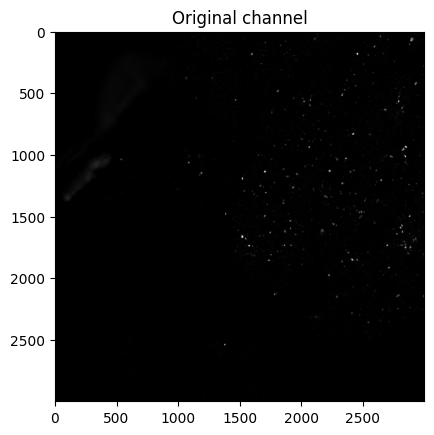

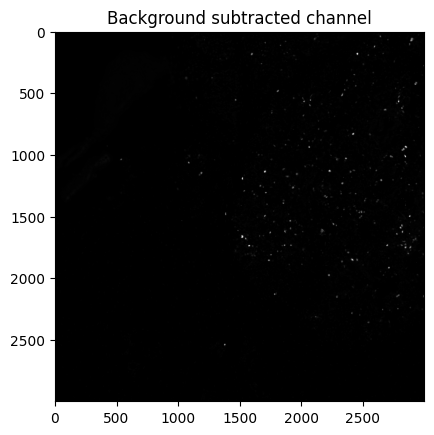

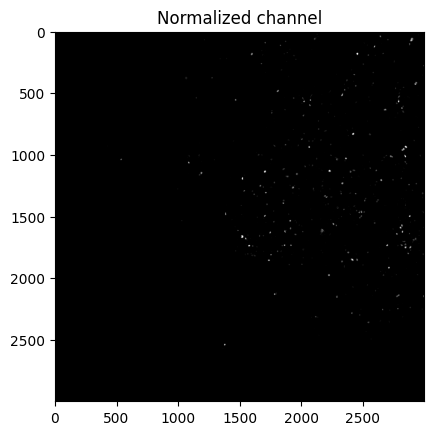

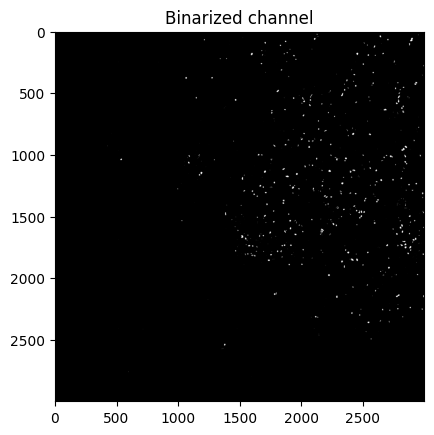

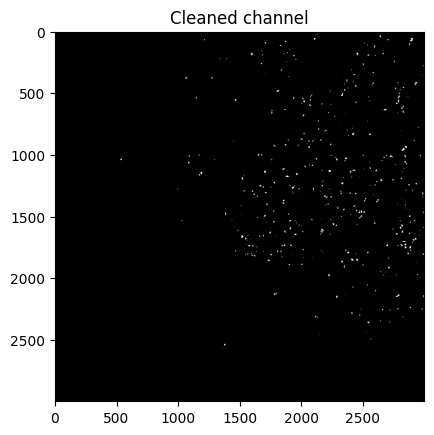

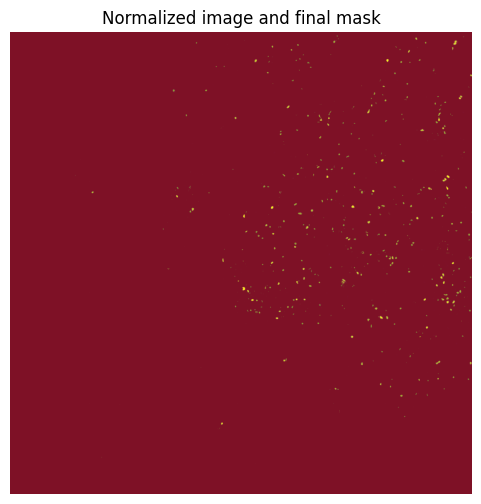

Done with Ki67



In [8]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/T2047-1_0.333F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2047-1_0.333F"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = sub_img, 
    markers_df = markers_df, 
    plot_intermediates = True, 
    plot_overlay= True, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = False, 
    cyto_markers = ["Ki67"],
    mem_markers = [],
    nuc_markers= [],
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## T2037-3_1.583M

In [37]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/T2037-3_1.583M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "T2037-3_1.583M"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P45_60M

In [38]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/P45_60M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P45_60M"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P58_74F

In [39]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/P58_74F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P58_74F"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P43_74M

In [40]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/P43_74M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P43_74M"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P46-B2_82F

In [41]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block5_patches/P46-B2_82F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P46-B2_82F"

thresh_keyword = "block5_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block5_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Block 6

In [3]:
block6_clip_threshs = {
    "K14"  : (5, 110), 
    'CD44' : (15, 75),
    'CD4'  : (0, 70),
    'CD8'  : (0, 70), 
    'CD3e' : (0, 60),
    'CD20' : (10, 45), 
    'b-Catenin1' : (35, 100),
    'Collagen IV' : (10, 22),
    'Bcl-2' : (10, 25), 
    'Ki67' : (15, 100), 
    'FOXP3' : (12, 39), 
    'TP63' : (28, 32),  # NOTE: This is only getting TP63 high nuclear stains. 
    'K5'   : (18, 91), 
    'CD68' : (20, 107), 
    'CD31' : (65, 193), # NOTE: This is only CD31 high, so really endothelial cells. 
    'Pan-Cytokeratin' : (10, 177), 
    'CD11c' : (20, 97), 
    'HLA-A' : (30, 161), 
    'Vimentin' : (40, 175), 
    'CD40' : (25, 65), 
    'K8' : (20, 85), 
    'HLA-DR' : (21, 122), 
    'K10' : (10, 116), 
    'CD141' : (10, 37), 
    'CD34' : (10, 87)
}

## T2110-1_0.025M

In [ ]:
plt.imshow(img[0,...], cmap="grey")
plt.show()

Starting Ki67
low percentile values: 15
high percentile value: 100
Ki67


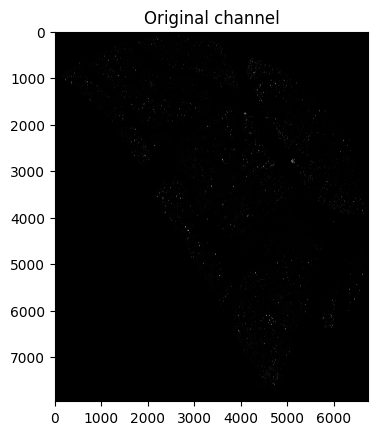

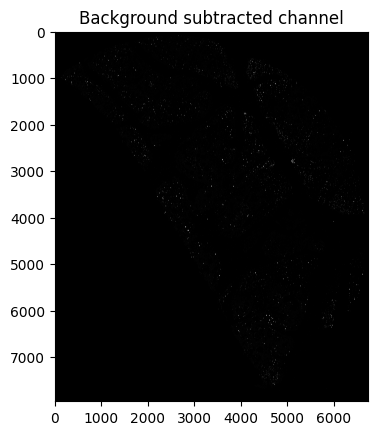

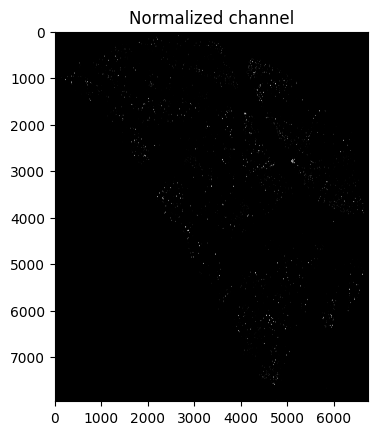

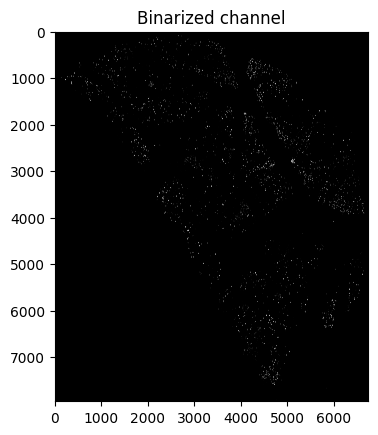

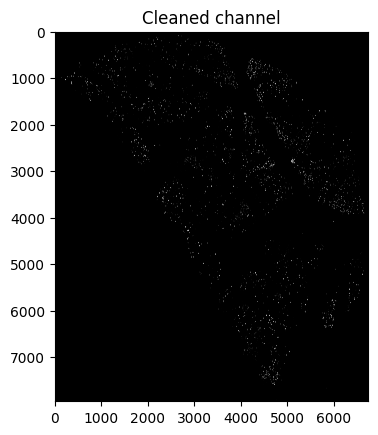

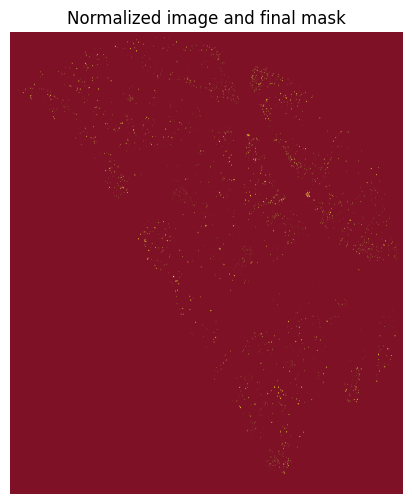

Done with Ki67



In [5]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/T2110-1_0.025M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))

subject_keyword = "T2110-1_0.025M"
thresh_keyword = "block6_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = True, 
    plot_overlay= True, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = False,
    cyto_markers = ["Ki67"],
    mem_markers = [],
    nuc_markers = [],
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P49_2M 

In [ ]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P49_2M/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))

subject_keyword = "P49_2M"
thresh_keyword = "block6_thresh"
size_keyword= "full"

new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True,
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P57_17F

In [45]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P57_17F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P57_17F"

thresh_keyword = "block6_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P42_54F

In [46]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P42_54F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P42_54F"

thresh_keyword = "block6_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## P44_64F

In [47]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/P44_64F/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "P44_64F"

thresh_keyword = "block6_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

## A3_18wkF

In [48]:
img_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/block6_patches/A3_18wkF/"
img = tifffile.imread(os.path.join(img_dir, "image.ome.tif"))
# sub_img = img[:, 1_000:4_000, 1_000:4_000]
markers_df = pd.read_csv(os.path.join(img_dir, "markers.csv"))
subject_keyword = "A3_18wkF"

thresh_keyword = "block6_thresh"
size_keyword= "full"
new_img = channel_mask_wrapper(
    img = img, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 21, # Size of the block used to determine the adaptive threshold, larger size sees more of the image, size 11 is too small
    save_new_img = False, 
    concat_new_img = False,
    save_masked_img = True, 
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = f"{subject_keyword}_{thresh_keyword}_{size_keyword}"
)

# Cuts 

In [ ]:
new_img = channel_mask_wrapper(
    img = img_test, 
    markers_df = markers_df, 
    plot_intermediates = False, 
    plot_overlay= False, 
    kernel_size = 2, # size of values that are removed. This is helpful for removing salt and pepper noise from binary mask.
    p_low= 75, # Values below this percentile are clipped to be 0 (This is more important than p_high because all remaining values get set to 1 anyway by the binary masking)
    p_high= 99, # Values above this percentile are clipped to be the max intensity
    C = -10, # Value subtracted from adaptive thresholding mean, lower C (constant) means higher threshold
    block_size = 2001, # Size of the block used to determine the adaptive threshold, larger size sees more of the image
    save_new_img = True, 
    concat_new_img = True,
    out_dir = img_dir, 
    manual_thresholds = block6_clip_threshs, 
    file_name = "P49_2M_manual_clipping_no_bg_removal"
)

# Collagen IV, TP63, CD31, need to be done separately
    # TP63 has intermediate expression and high expression. We can't distinguish that with this binarized approach. We really only care about the high expression for identifying TP63+ TECs. 
    # CD31 likewise has intermediate staining and high staining. The high staining is true endothelial cells. I'm not sure why other medullary cells are staining positive. It could be bleed through from another channel.
    # Collagen IV is low signal here. Manual thresholding in qupath gets it to look okay, but it's hard to make sense of the stain. We don't really need it though. 

In [ ]:
# Marker names 
mem_markers = ['CD44', 'CD4', 'CD8', 'CD20', 'CD3e', 'b-Catenin1', 'Collagen IV', 'Bcl-2']
nuc_markers = ['Ki67', 'FOXP3', 'TP63']
cyto_markers = ['K5', 'CD68', 'CD31', 'K14', 'Pan-Cytokeratin', 'CD11c', 'HLA-A', 'Vimentin', 'CD40', 'K8', 'HLA-DR', 'K10', 'CD141', 'CD34']

# Get channel indices 
mem_channel_indices = markers_df.loc[markers_df["marker_name"].isin(mem_markers), "row_num"].tolist()
nuc_channel_indices = markers_df.loc[markers_df["marker_name"].isin(nuc_markers), "row_num"].tolist()
cyto_channel_indices = markers_df.loc[markers_df["marker_name"].isin(cyto_markers), "row_num"].tolist()

print(mem_channel_indices)
print(nuc_channel_indices)
print(cyto_channel_indices)

In [ ]:
mem_channel_indices = [6, 13, 14, 15, 26]  
nuc_channel_indices = []
cytoplasm_channel_indices = []

all_marker_indices = mem_channel_indices + nuc_channel_indices + cytoplasm_channel_indices 
masks = {}
img = img_test
for c in all_marker_indices:
    print(f"Channel index: {c}")
    thresh_channel = membrane_mask_from_channel(img[c], plot_intermediates = True, plot_overlay = True)
    # masks[c] = thresh_channel

In [ ]:
mem_markers = ['CD44', 'CD4', 'CD8', 'CD20', 'CD3e', 'b-Catenin1', 'Collagen IV', 'Bcl-2']
nuc_markers = ['Ki67', 'FOXP3', 'TP63']
cyto_markers = ['K5', 'CD68', 'CD31', 'K14', 'Pan-Cytokeratin', 'CD11c', 'HLA-A', 'Vimentin', 'CD40', 'K8', 'HLA-DR', 'K10', 'CD141', 'CD34']
all_marker_names = mem_markers + nuc_markers + cyto_markers  
print(all_marker_names)
    
all_marker_indices = [markers_df.loc[markers_df["marker_name"] == marker_name, "row_num"].values[0] for marker_name in all_marker_names]
all_marker_indices
print(all_marker_indices)